# How to Audit ML Training Metrics: Marginal Baseline Eval

A training metric can look impressive for the wrong reason. Sometimes a reported improvement is real; sometimes it is mostly a weak baseline, a lucky seed, a noisy validation split, or a pooled correlation hiding ordinary training conditions.

This notebook gives a compact, reproducible audit workflow using **Marginal Baseline Evaluation (MBE)**. We will:

- compare a baseline model to an improved model,
- show uncertainty with bootstrap confidence intervals,
- detect weak-baseline artifacts,
- run MBE on several candidate training metrics,
- generate a clean markdown audit report.

Package: [`mbe-eval` on PyPI](https://pypi.org/project/mbe-eval/)  
Code: [GitHub repo](https://github.com/AparajeetS/marginal-baseline-eval)  
Support: [GitHub Sponsors](https://github.com/sponsors/AparajeetS)

**Scope:** This notebook demonstrates the stable MBE v1 linear partial-rank audit on synthetic data. The active MBE 2.0 research program adds cross-fitted nonlinear baselines, transport, and intervention tests; those are not implemented in this notebook.


## The Problem

A model can appear to improve because the new method is better. It can also appear to improve because the baseline was unusually weak.

MBE asks a stricter question: after controlling for ordinary baseline variables such as baseline accuracy, noise, compute budget, architecture, and task family, does the metric still predict the held-out outcome?

In this demo, `test_gain` is the held-out improvement we care about. The candidate metrics include a noisy reported gain, a validation-style gain, a training-only gain, a parameter-change proxy, and a random metric.


In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec('mbe_eval') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'https://github.com/AparajeetS/marginal-baseline-eval/releases/download/v0.5.0/mbe_eval-0.5.0-py3-none-any.whl'])


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from mbe_eval import audit_metrics

pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 3)
plt.style.use('seaborn-v0_8-whitegrid')


## Create a Small Training-Run Ledger

Each row below acts like one trained model/run. The data are synthetic so the notebook is fast and fully reproducible, but the columns mirror the audit table you would build from real experiments.


In [3]:
def make_demo_runs(n=160, seed=9):
    rng = np.random.default_rng(seed)

    suite = rng.choice(['image', 'text'], size=n, p=[0.60, 0.40])
    arch = rng.choice(['small_cnn', 'resnet_tiny', 'tiny_transformer'], size=n)
    compute_budget = rng.choice([1, 2, 4], size=n, p=[0.45, 0.35, 0.20])
    regularization = rng.choice(['low', 'medium', 'high'], size=n, p=[0.30, 0.50, 0.20])
    weak_baseline = rng.random(n) < 0.38

    suite_effect = np.where(suite == 'image', 0.014, -0.004)
    arch_effect = np.select(
        [arch == 'resnet_tiny', arch == 'tiny_transformer'],
        [0.012, 0.004],
        default=-0.006,
    )
    reg_effect = np.select(
        [regularization == 'medium', regularization == 'high'],
        [0.010, 0.002],
        default=-0.007,
    )

    baseline_noise = np.where(
        weak_baseline,
        rng.uniform(0.035, 0.075, n),
        rng.uniform(0.006, 0.025, n),
    )
    baseline_acc = 0.70 + suite_effect + arch_effect + rng.normal(0, 0.035, n)
    baseline_acc = np.clip(baseline_acc - weak_baseline * 0.075, 0.45, 0.92)

    true_gain = (
        0.006
        + 0.008 * np.log2(compute_budget)
        + 0.70 * reg_effect
        + rng.normal(0, 0.010, n)
    )
    mechanical_recovery = weak_baseline * 0.030 + baseline_noise * 0.080
    test_gain = true_gain + mechanical_recovery + rng.normal(0, 0.008, n)

    reported_gain = weak_baseline * 0.065 + baseline_noise * 0.600 + rng.normal(0, 0.018, n)
    validation_gain = test_gain + 0.450 * true_gain + rng.normal(0, 0.008, n)
    train_gain = reported_gain + rng.normal(0, 0.012, n)
    parameter_delta = 0.006 * np.log2(compute_budget) + weak_baseline * 0.018 + rng.normal(0, 0.014, n)
    random_metric = rng.normal(0, 1, n)

    improved_acc = np.clip(baseline_acc + test_gain, 0.45, 0.97)
    weak_baseline_score = (0.80 - baseline_acc) + baseline_noise * 2.0

    return pd.DataFrame({
        'suite': suite,
        'arch': arch,
        'compute_budget': compute_budget,
        'regularization': regularization,
        'weak_baseline': weak_baseline.astype(int),
        'baseline_acc': baseline_acc,
        'improved_acc': improved_acc,
        'baseline_noise': baseline_noise,
        'weak_baseline_score': weak_baseline_score,
        'test_gain': test_gain,
        'reported_gain': reported_gain,
        'validation_gain': validation_gain,
        'train_gain': train_gain,
        'parameter_delta': parameter_delta,
        'random_metric': random_metric,
    })

df = make_demo_runs()
df.head()


,suite,arch,compute_budget,regularization,weak_baseline,baseline_acc,improved_acc,baseline_noise,weak_baseline_score,test_gain,reported_gain,validation_gain,train_gain,parameter_delta,random_metric
0,text,small_cnn,2,low,0,0.672,0.683,0.010,0.148,0.011,1.718e-02,0.022,0.006,0.006,1.845
1,image,tiny_transformer,1,low,1,0.610,0.622,0.042,0.274,0.012,6.242e-02,0.012,0.066,0.006,1.701
2,text,small_cnn,4,medium,1,0.628,0.689,0.063,0.299,0.061,9.847e-02,0.070,0.104,0.017,-2.290
3,text,resnet_tiny,1,medium,0,0.646,0.638,0.023,0.200,-0.007,3.747e-03,-0.012,-0.016,0.004,0.492
4,text,small_cnn,4,high,0,0.768,0.802,0.023,0.078,0.034,7.314e-04,0.055,0.030,0.008,1.452


## Baseline vs Improved Model

First, do the ordinary comparison. The improved model has higher mean accuracy, but we should also quantify variance instead of treating one average as the whole story.


In [4]:
def bootstrap_mean_ci(values, n_boot=1500, seed=0):
    rng = np.random.default_rng(seed)
    values = np.asarray(values, dtype=float)
    means = [rng.choice(values, size=len(values), replace=True).mean() for _ in range(n_boot)]
    return values.mean(), np.quantile(means, 0.025), np.quantile(means, 0.975)

baseline_mean, baseline_low, baseline_high = bootstrap_mean_ci(df['baseline_acc'], seed=1)
improved_mean, improved_low, improved_high = bootstrap_mean_ci(df['improved_acc'], seed=2)
gain_mean, gain_low, gain_high = bootstrap_mean_ci(df['improved_acc'] - df['baseline_acc'], seed=3)

comparison = pd.DataFrame([
    {'quantity': 'baseline accuracy', 'mean': baseline_mean, 'ci_low': baseline_low, 'ci_high': baseline_high},
    {'quantity': 'improved accuracy', 'mean': improved_mean, 'ci_low': improved_low, 'ci_high': improved_high},
    {'quantity': 'accuracy gain', 'mean': gain_mean, 'ci_low': gain_low, 'ci_high': gain_high},
])
comparison


,quantity,mean,ci_low,ci_high
0,baseline accuracy,0.682,0.673,0.690
1,improved accuracy,0.712,0.704,0.719
2,accuracy gain,0.030,0.026,0.033


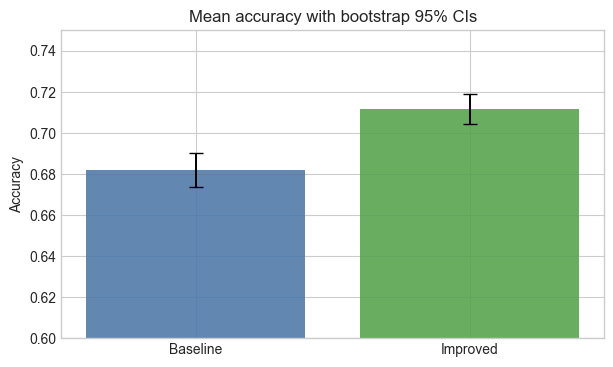

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_df = comparison.iloc[:2].copy()
x = np.arange(len(plot_df))
yerr = np.vstack([plot_df['mean'] - plot_df['ci_low'], plot_df['ci_high'] - plot_df['mean']])
ax.bar(x, plot_df['mean'], color=['#4C78A8', '#54A24B'], alpha=0.88)
ax.errorbar(x, plot_df['mean'], yerr=yerr, fmt='none', color='black', capsize=5, lw=1.4)
ax.set_xticks(x, ['Baseline', 'Improved'])
ax.set_ylim(0.60, 0.75)
ax.set_ylabel('Accuracy')
ax.set_title('Mean accuracy with bootstrap 95% CIs')
plt.show()


## Detect a Weak Baseline

The average improvement is not enough. Weak baselines are easier to beat, noisier, and can create a misleading sense of progress. Here we inspect whether the apparent gain is concentrated in weak-baseline runs.


In [6]:
weak_table = (
    df.groupby('weak_baseline')
    .agg(
        runs=('test_gain', 'size'),
        baseline_acc=('baseline_acc', 'mean'),
        baseline_noise=('baseline_noise', 'mean'),
        reported_gain=('reported_gain', 'mean'),
        heldout_test_gain=('test_gain', 'mean'),
    )
    .rename(index={0: 'stronger baseline', 1: 'weak baseline'})
)
weak_table


,runs,baseline_acc,baseline_noise,reported_gain,heldout_test_gain
weak_baseline,,,,,
stronger baseline,97,0.713,0.015,0.006,0.016
weak baseline,63,0.634,0.057,0.100,0.050


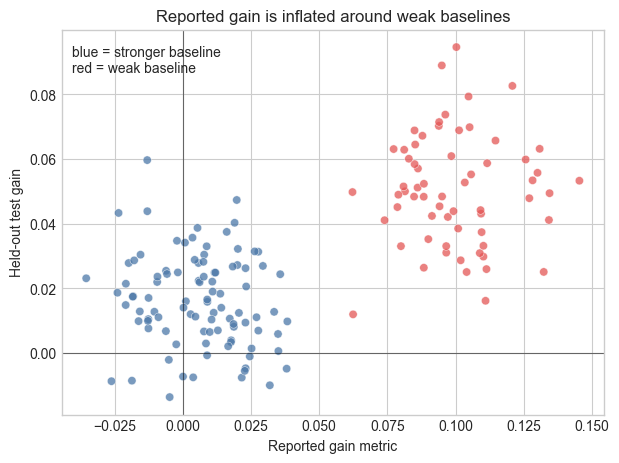

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = df['weak_baseline'].map({0: '#4C78A8', 1: '#E45756'})
ax.scatter(df['reported_gain'], df['test_gain'], c=colors, alpha=0.75, edgecolor='white', linewidth=0.4)
ax.axhline(0, color='black', lw=0.8, alpha=0.5)
ax.axvline(0, color='black', lw=0.8, alpha=0.5)
ax.set_xlabel('Reported gain metric')
ax.set_ylabel('Held-out test gain')
ax.set_title('Reported gain is inflated around weak baselines')
ax.text(0.02, 0.96, 'blue = stronger baseline\nred = weak baseline', transform=ax.transAxes, va='top')
plt.show()


## Run Marginal Baseline Evaluation

Now we audit the metrics. Raw correlation asks whether a metric is associated with the target. MBE asks whether that association remains after controlling for baseline quality and experimental design variables.

Controls used here: baseline accuracy, baseline noise, weak-baseline flag, compute budget, task suite, architecture, and regularization.


In [8]:
metrics = [
    'reported_gain',
    'validation_gain',
    'train_gain',
    'parameter_delta',
    'random_metric',
]
controls = [
    'baseline_acc',
    'baseline_noise',
    'weak_baseline',
    'compute_budget',
    'suite',
    'arch',
    'regularization',
]

audit = audit_metrics(
    df,
    metrics=metrics,
    target='test_gain',
    controls=controls,
    bootstrap=200,
    seed=42,
)

cols = [
    'metric',
    'n',
    'raw_r',
    'raw_ci_low',
    'raw_ci_high',
    'partial_r',
    'partial_ci_low',
    'partial_ci_high',
    'classification',
]
audit[cols].sort_values('partial_r', key=lambda s: s.abs(), ascending=False)


,metric,n,raw_r,raw_ci_low,raw_ci_high,partial_r,partial_ci_low,partial_ci_high,classification
1,validation_gain,160,0.936,0.902,0.951,0.864,0.805,8.994e-01,survives
0,reported_gain,160,0.582,0.482,0.659,-0.172,-0.326,-6.621e-05,weak-or-mixed
3,parameter_delta,160,0.404,0.274,0.506,-0.050,-0.207,7.080e-02,washout
2,train_gain,160,0.619,0.529,0.685,-0.045,-0.216,1.112e-01,washout
4,random_metric,160,0.063,-0.102,0.237,0.038,-0.152,2.097e-01,weak-or-mixed


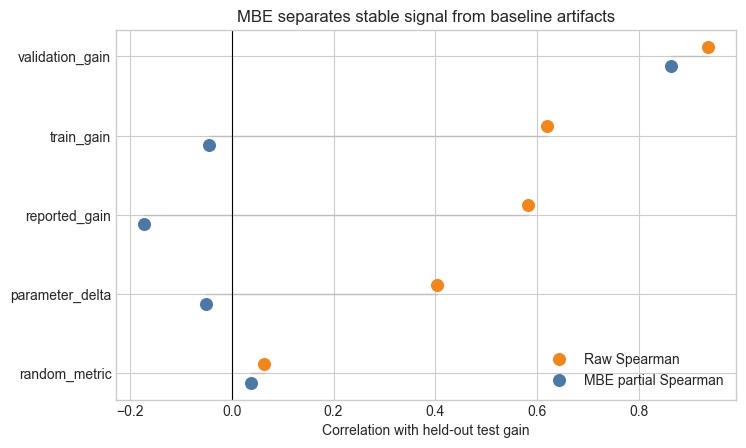

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.8))
plot_audit = audit.sort_values('raw_r')
y = np.arange(len(plot_audit))
ax.scatter(plot_audit['raw_r'], y + 0.12, label='Raw Spearman', color='#F58518', s=70)
ax.scatter(plot_audit['partial_r'], y - 0.12, label='MBE partial Spearman', color='#4C78A8', s=70)
for _, row in plot_audit.iterrows():
    yi = list(plot_audit['metric']).index(row['metric'])
    ax.plot([row['raw_r'], row['partial_r']], [yi, yi], color='0.75', lw=1)
ax.axvline(0, color='black', lw=0.8)
ax.set_yticks(y, plot_audit['metric'])
ax.set_xlabel('Correlation with held-out test gain')
ax.set_title('MBE separates stable signal from baseline artifacts')
ax.legend(loc='lower right')
plt.show()


## Generate a Clean Audit Report

A useful metric audit should leave behind a small artifact someone else can read without rerunning the notebook. The report below records the data size, controls, baseline warning, and metric verdicts.


In [10]:
def ci_text(row, prefix):
    low = row[f'{prefix}_ci_low']
    high = row[f'{prefix}_ci_high']
    value = row['raw_r'] if prefix == 'raw' else row['partial_r']
    return f"{value:+.3f} [{low:+.3f}, {high:+.3f}]"

weak_share = df['weak_baseline'].mean()
gain_summary = comparison.set_index('quantity').loc['accuracy gain']
top_rows = audit[cols].copy().sort_values('partial_r', key=lambda s: s.abs(), ascending=False)

lines = [
    '# MBE Training-Metric Audit Report',
    '',
    f'- Runs audited: {len(df)}',
    f'- Held-out target: `test_gain`',
    f'- Mean baseline-to-improved gain: {gain_summary['mean']:+.3f} '
    f"[{gain_summary['ci_low']:+.3f}, {gain_summary['ci_high']:+.3f}]",
    f'- Weak-baseline share: {weak_share:.1%}',
    f'- Controls: {', '.join(controls)}',
    '',
    '## Metric Verdicts',
    '',
    '| Metric | Raw rho, 95% CI | MBE partial rho, 95% CI | Verdict |',
    '|---|---:|---:|---|',
]

for _, row in top_rows.iterrows():
    lines.append(
        f"| `{row['metric']}` | {ci_text(row, 'raw')} | {ci_text(row, 'partial')} | {row['classification']} |"
    )

lines += [
    '',
    '## Interpretation',
    '',
    '- A raw metric can look useful because weak baselines are easier to beat.',
    '- A metric that survives MBE keeps signal after baseline and design controls.',
    '- A washout or weak/mixed result should not be used as standalone evidence of model improvement.',
    '',
    'Package: https://pypi.org/project/mbe-eval/',
    'GitHub: https://github.com/AparajeetS/marginal-baseline-eval',
    'Sponsors: https://github.com/sponsors/AparajeetS',
]

report_text = '\n'.join(lines)
Path('mbe_audit_report.md').write_text(report_text, encoding='utf-8')
print(report_text)


# MBE Training-Metric Audit Report

- Runs audited: 160
- Held-out target: `test_gain`
- Mean baseline-to-improved gain: +0.030 [+0.026, +0.033]
- Weak-baseline share: 39.4%
- Controls: baseline_acc, baseline_noise, weak_baseline, compute_budget, suite, arch, regularization

## Metric Verdicts

| Metric | Raw rho, 95% CI | MBE partial rho, 95% CI | Verdict |
|---|---:|---:|---|
| `validation_gain` | +0.936 [+0.902, +0.951] | +0.864 [+0.805, +0.899] | survives |
| `reported_gain` | +0.582 [+0.482, +0.659] | -0.172 [-0.326, -0.000] | weak-or-mixed |
| `parameter_delta` | +0.404 [+0.274, +0.506] | -0.050 [-0.207, +0.071] | washout |
| `train_gain` | +0.619 [+0.529, +0.685] | -0.045 [-0.216, +0.111] | washout |
| `random_metric` | +0.063 [-0.102, +0.237] | +0.038 [-0.152, +0.210] | weak-or-mixed |

## Interpretation

- A raw metric can look useful because weak baselines are easier to beat.
- A metric that survives MBE keeps signal after baseline and design controls.
- A washout or weak/mix

## Legacy Kaggle-Scale Pilot Evidence

The walkthrough above uses synthetic data so anyone can run it quickly. The research repo also preserves result artifacts from a legacy 680-row exploratory pilot:

- 480 CIFAR-10 image models.
- 200 character-transformer language models.
- Default controls: `lr`, `wd`, `dropout`, `optimizer`, `arch`, `task`, `seed`.
- Strict controls additionally include `val_loss`.

This ledger contains repeated configurations, and its character-transformer text setup lacks a causal attention mask and permits label leakage. It is retained for provenance and protocol development, not as confirmatory language-model evidence.

FIM_norm is the motivating stress-test case:

| Audit | n | Raw rho | MBE partial rho | Class |
|---|---:|---:|---:|---|
| Image only, default controls | 480 | -0.662 | -0.218 | survives |
| Text only, default controls | 200 | -0.291 | +0.014 | washout |
| Full image+text pool | 680 | +0.225 | -0.203 | reverse-inversion |
| Full pool, also controlling validation loss | 680 | +0.225 | -0.300 | reverse-inversion |

The broader pattern is selective rather than uniformly destructive: several familiar predictors survive MBE, while FIM_norm, feature-rank, weight-norm, and distance/update proxies weaken, wash out, or invert in key pooled settings.

Full result tables and artifact hashes are in the GitHub repo:

- [Legacy pilot audit summary](https://github.com/AparajeetS/marginal-baseline-eval/blob/master/experiments/07_jmlr_scale/jmlr_full_confirmed_680_audit_summary.md)
- [Legacy strict loss-control summary](https://github.com/AparajeetS/marginal-baseline-eval/blob/master/experiments/07_jmlr_scale/jmlr_full_confirmed_680_strict_loss_mbe_summary.md)
- [`ARTIFACTS.md`](https://github.com/AparajeetS/marginal-baseline-eval/blob/master/experiments/07_jmlr_scale/ARTIFACTS.md)


## Takeaway

The point of MBE is not to declare every new metric bad. It is to make the failure mode visible. A metric should earn trust by surviving the baselines a careful reviewer would naturally ask about.

For real projects, replace the synthetic dataframe with your training-run ledger: one row per model, columns for candidate metrics, one held-out target, and controls for the conditions under which each model was trained.

- GitHub: [AparajeetS/marginal-baseline-eval](https://github.com/AparajeetS/marginal-baseline-eval)
- PyPI: [`mbe-eval`](https://pypi.org/project/mbe-eval/)
- Sponsors: [github.com/sponsors/AparajeetS](https://github.com/sponsors/AparajeetS)
